I have condensed much of my routines to fit in here. Having done this does not have any effect anywhere else during the tuning or training process since they are built of these smaller simple blocks. Much of the modifications come from adapting it to either AWS instance or [ray tune](https://docs.ray.io/en/latest/tune/index.html). If you believe there to be any issues with the adaptions, I could explain how I used them but all my code is commited to the github repo. Below are the imports

In [23]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from tqdm import tqdm

import math
import json
import os

torch.manual_seed(42)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [24]:
def load_data(type: str):
    """type: ['train','val','test']"""
    X_data  = torch.load(os.path.join(".." ,"Data",f"X_{type}.pt"))
    Y_data  = torch.load(os.path.join(".." ,"Data",f"Y_{type}.pt"))
    return DataLoader(TensorDataset(X_data,Y_data),batch_size=32,shuffle=False, pin_memory=True)

def save_json(data,filepath): 
    with open(filepath, mode = 'w+') as f:
        json.dump(data,fp = f)

def load_json(filepath):
    with open(filepath, mode = 'r') as f:
        data = json.load(f)
    return data

The only modification I made to the model object is to inlcude the embedding table within its init.

In [25]:
class ConvAttnPool(nn.Module):
    def __init__(self, table_path,label_space = 50, num_of_filters = 10, kernel_size = 3, drop_out = 0.2):
        super().__init__()
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape
        embed_table = torch.from_numpy(model.wv.vectors).type(torch.float32)
        embed_table = torch.concat([embed_table,torch.zeros(size = (1,embed_d))], dim = 0)

        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table,padding_idx=vocab_size)
        self.conv  = nn.Conv1d(embed_d, num_of_filters, kernel_size = kernel_size, padding = int(math.floor(kernel_size//2)))
        self.U     = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)
        self.embed_drop     = nn.Dropout(p = drop_out)
        self.embedding_size = embed_d

    def forward(self, x):
        x = self.embed(x)
        x = self.embed_drop(x)
        x = x.transpose (1, 2)
        x = F. tanh(self.conv(x).transpose(1,2))
        alpha = F.softmax(self.U.weight.matmul(x.transpose (1,2)) , dim=2)
        m     = alpha.matmul(x)
        y     = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)
        return y, alpha
    
def GenerateModel(table_path, num_of_filters = 15,kernel_size = 5):
    return ConvAttnPool(
            table_path     = table_path,
            drop_out       = 0.2,
            num_of_filters = num_of_filters,
            label_space    = 50, 
            kernel_size    = kernel_size
            )

model = GenerateModel(table_path=os.path.join('..','Model','processed_full.w2v'))
model

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
  (embed_drop): Dropout(p=0.2, inplace=False)
)

Here I just demonstrate the Fed Average using random tensors. It stacks them and averages the integers

In [26]:
def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> nn.Module:
    for key in global_model.keys():
        stacked = torch.stack([client_dict[key].float() for client_dict in client_state_dicts], dim=0)
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [27]:
g_param = {
    'layer1' : torch.zeros(size = (4,4))
}
c_param = [{'layer1' : torch.randint(low=0,high = 10, size = (4,4))} for _ in range(3) ]
print("Global Model",g_param['layer1']) 
print(c_param[0]['layer1'])
print(c_param[1]['layer1'])
print(c_param[2]['layer1'])

g_param = FedAvg(global_model=g_param,client_state_dicts=c_param)
g_param

Global Model tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[6, 2, 9, 9],
        [2, 5, 2, 6],
        [6, 3, 0, 3],
        [0, 7, 1, 2]])
tensor([[9, 6, 8, 8],
        [0, 4, 7, 8],
        [7, 9, 0, 5],
        [0, 1, 7, 9]])
tensor([[8, 3, 4, 3],
        [5, 1, 7, 6],
        [4, 9, 3, 8],
        [0, 4, 6, 9]])


{'layer1': tensor([[7.6667, 3.6667, 7.0000, 6.6667],
         [2.3333, 3.3333, 5.3333, 6.6667],
         [5.6667, 7.0000, 1.0000, 5.3333],
         [0.0000, 4.0000, 4.6667, 6.6667]])}

The client update is just a normal training routine that is wrapped in a func

In [28]:
def client_update(model : nn.Module , 
                  train_loader: DataLoader, 
                  epochs: int = 1, lr: float = 0.1, device : str = 'cpu') -> dict:
    model.to(device)
    model.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr = lr, betas =  (0.9,0.99))
    loss_fn   = nn.BCEWithLogitsLoss()

    for _ in (range(epochs)):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, alpha = model(X_batch)
            loss = loss_fn(preds, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return loss.item(), model.state_dict()

In [29]:
train_laoder = load_data(type = 'train')
local_loss, local_param = client_update(model = model, train_loader=train_laoder, epochs=1, device='cpu')
print(local_loss,local_param['embed.weight'])

0.23738987741016207 tensor([[ 1.3710e+00, -1.1058e+00,  2.0421e+00,  ..., -2.6081e+00,
          9.1003e-01,  8.2254e-01],
        [ 1.5817e+00, -4.5227e-01,  4.5332e-01,  ...,  1.7618e-01,
          7.6717e-01,  1.1082e+00],
        [ 6.9607e-01,  6.6233e-01, -8.9618e-01,  ..., -4.3699e-01,
          7.8535e-01,  1.9697e+00],
        ...,
        [ 7.2904e-03, -9.4383e-04, -2.5926e-02,  ...,  1.3076e-02,
         -2.7830e-02,  1.5075e-02],
        [ 5.7946e-03,  3.3857e-03,  2.6939e-02,  ..., -1.9374e-02,
          2.0232e-02,  1.2402e-02],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])


In [30]:
# Unraveled to explain function!
# def federate_model(config: dict, model_param: dict):
#     """
#     config
#         batch_size
#         lr
#         n_filters
#         window_size
#         epochs
#         rounds
#     """

config = {
    "batch_size" : 32,
    "lr"         : 0.00001,
    "n_filters"  : 21,
    "window_size": 6,
    "epochs"     : 2,
    "rounds"     : 0
}

model_param_path = os.path.join('..','Model','processed_full.w2v')
# Training Data
X_train  = torch.load(os.path.join(".." ,"Data",f"X_train.pt"))
Y_train  = torch.load(os.path.join(".." ,"Data",f"Y_train.pt"))
################################## Split the dataset three ways
train = TensorDataset(X_train,Y_train)

c1, c2, c3 = random_split(train,lengths=[0.33,0.33,0.34])
c1_loader  = DataLoader(c1, batch_size = config['batch_size'], shuffle = True)
c2_loader  = DataLoader(c2, batch_size = config['batch_size'], shuffle = True)
c3_loader  = DataLoader(c3, batch_size = config['batch_size'], shuffle = True)
c_loaders  = [c1_loader, c2_loader, c3_loader]

In [31]:
print("train size: ",train.tensors[1].shape)
print("c1 size: ", Y_train[c1.indices].shape)
print("c2 size: ", Y_train[c2.indices].shape)
print("c3 size: ", Y_train[c3.indices].shape)

train size:  torch.Size([6453, 50])
c1 size:  torch.Size([2130, 50])
c2 size:  torch.Size([2129, 50])
c3 size:  torch.Size([2194, 50])


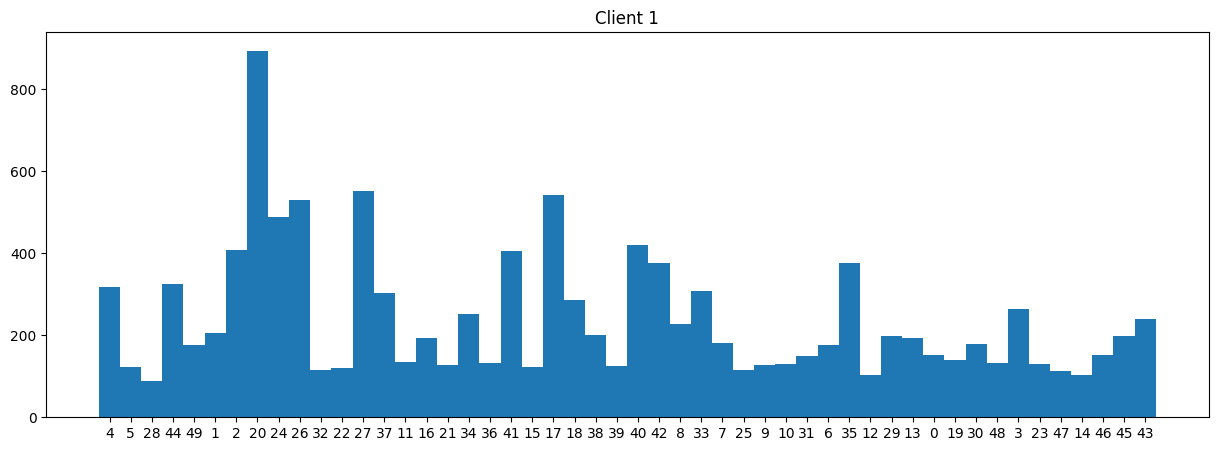

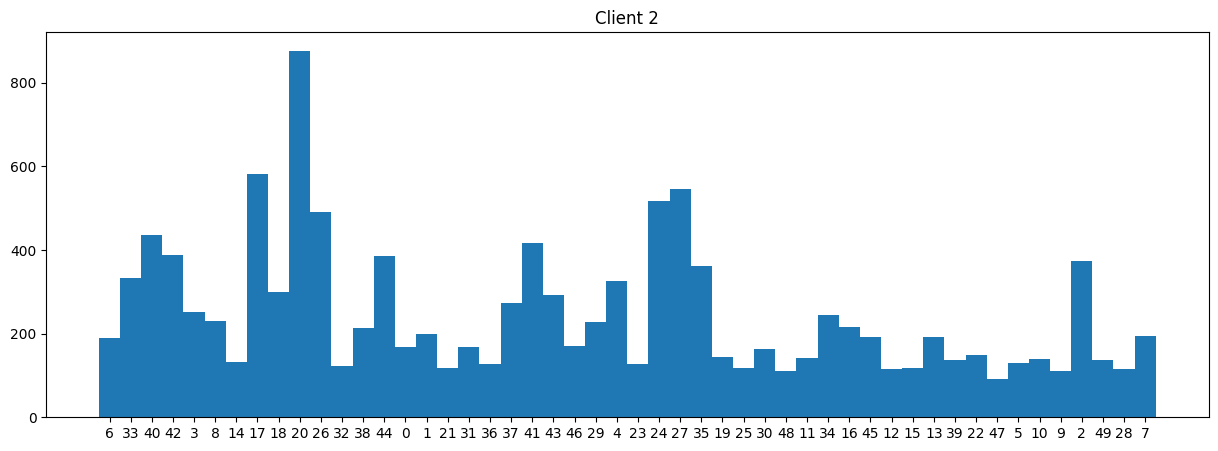

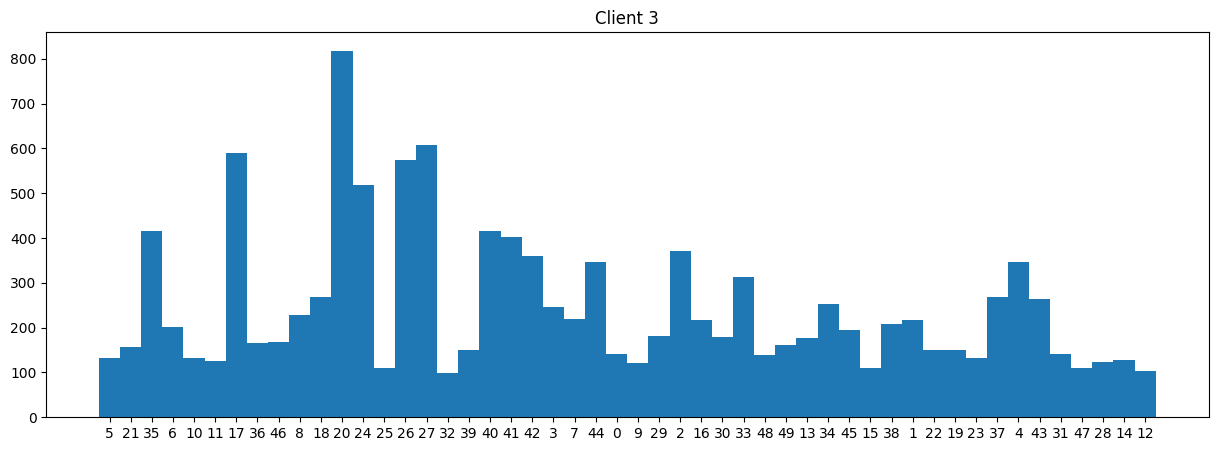

In [32]:
for idx,c in enumerate([c1,c2,c3]):
    all_codes = [code for instance in Y_train[c.indices] for code in torch.where(instance > 0)[0].tolist() ]
    all_codes = Counter(all_codes)
    labels, values = zip(*all_codes.items())
    indexes = np.arange(len(labels))

    plt.figure(figsize=(15,5))
    plt.title(f'Client {idx + 1}')
    plt.bar(indexes, values, 1)
    plt.xticks(indexes, labels)
    plt.show()

In [33]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Device: {device}')

Global_Model = GenerateModel(table_path     = model_param_path,
                             num_of_filters = config['n_filters'], 
                             kernel_size    = config['window_size'])

client = GenerateModel(table_path     = model_param_path,
                       num_of_filters = config['n_filters'], 
                       kernel_size    = config['window_size'])

Device: cuda


In [34]:
from evaluation      import all_metrics
@torch.no_grad()
def eval_model(model, device, data_loader):
    model.eval()
    model.to(device)
    all_pred     = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels   = torch.empty((0,), dtype = torch.float32).to(device)
    all_pred_raw = torch.empty((0,), dtype = torch.float32).to(device)
    loss_fn   = nn.CrossEntropyLoss()
    total_loss = 0

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds, _    = model(data_inputs)
        loss = loss_fn(preds, data_labels)
        total_loss += loss.item()
        pred_labels = (F.sigmoid(preds) >= 0.5).long()
        all_pred     = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels   = torch.cat((all_labels,data_labels), dim = 0)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim = 0)

    return total_loss, all_metrics(yhat = all_pred.cpu().numpy(), y = all_labels.cpu().numpy(), yhat_raw=all_pred_raw.cpu().numpy())

In [35]:
history = {
    "local_loss": {
        0 : [],
        1 : [],
        2 : []
    },
    "global_loss": [],
    "global_metrics": []
}
val_loader = load_data(type = 'val')
max_auc_macro = 0
max_f1_micro  = 0

config['rounds'] = 100
################################
for rnds in tqdm(range(config['rounds']), colour='blue'):
    c_parameters = []
    ################################
    for c_idx in range(3):
        client.load_state_dict(Global_Model.state_dict())
        local_loss, c_param = client_update(model  = client,
                                epochs = config['epochs'],
                                lr     = config['lr'],
                                device = device,
                                train_loader = c_loaders[c_idx])
        c_parameters.append(c_param)
        history['local_loss'][c_idx].append(local_loss)
    ################################ Aggregate and load our param back to global to distribute back to the clients
    new_param = FedAvg(Global_Model.state_dict(), c_parameters)
    Global_Model.load_state_dict(new_param)
    ################################ Take a snapshot every 100 rounds
    if rnds % 100:
        g_loss, metrics = eval_model(model = Global_Model,device = device,data_loader=val_loader)
        history['global_metrics'].append(metrics)
        history['global_loss'].append(g_loss)
        save_json(data = history, filepath='../History/logs/metric_history.json')
        torch.save(Global_Model.state_dict(), f = os.path.join("..",'History','logs','latest_model.pt'))
        ################ Save the models
        if metrics['auc_macro'] > max_auc_macro:
            # log_detail(desc = f'max auc_macro: {max_auc_macro:,.4f}->{val_hist['auc_macro']:,.4f};{round}',file = logging_path)
            max_auc_macro = metrics['auc_macro']
            torch.save(Global_Model.state_dict(), f = os.path.join("..",'History','logs','max_auc.pt'))
        if metrics['f1_micro'] > max_f1_micro:
            max_f1_micro = metrics['f1_micro']
            torch.save(Global_Model.state_dict(), f = os.path.join("..",'History','logs','max_f1_micro.pt'))

################################

100%|██████████| 100/100 [12:17<00:00,  7.38s/it]


----

In [36]:
history = load_json(filepath='../History/logs/metric_history.json')
print(len(history['global_loss']))

99


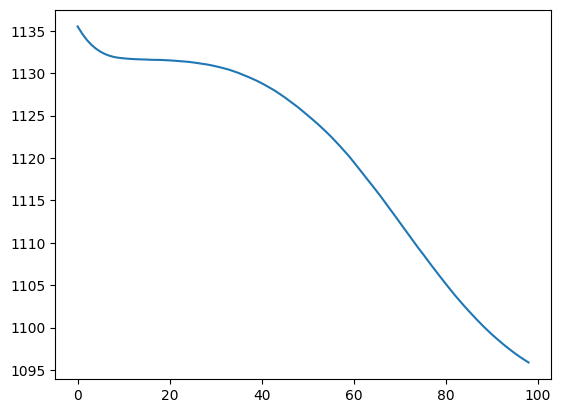

In [37]:
plt.plot(history['global_loss'], label = "Global Loss")
plt.show()

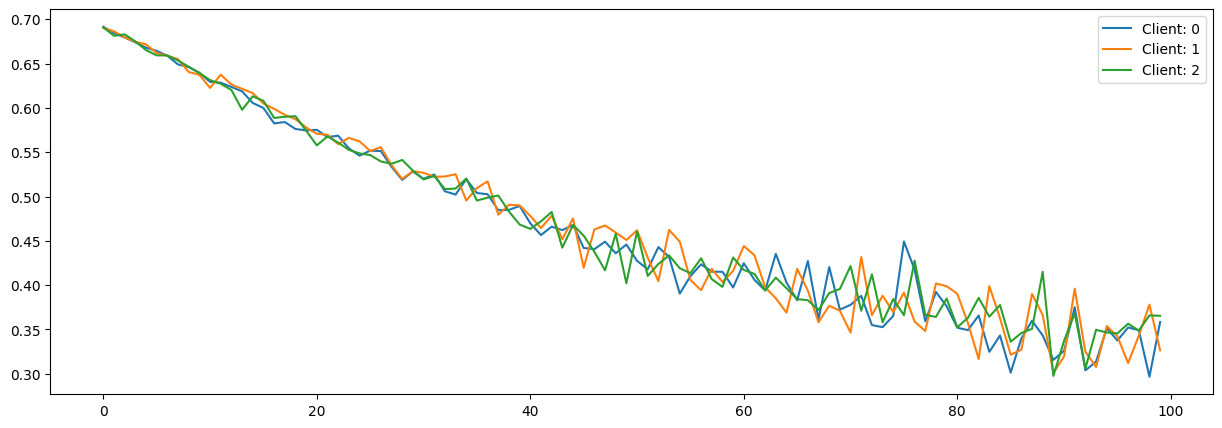

In [38]:
plt.figure(figsize=(15,5))
for c_idx in range(3):
    plt.plot(history['local_loss'][str(c_idx)], label = f'Client: {c_idx}')
plt.legend()
plt.show()

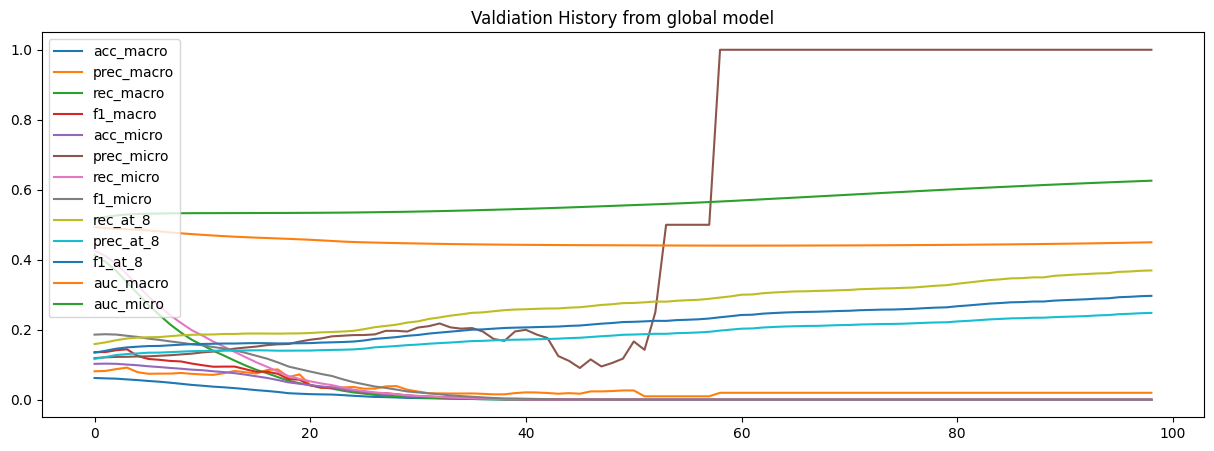

In [39]:
plt.figure(figsize=(15,5))
plt.title("Valdiation History from global model")
for key in history['global_metrics'][0].keys():
    plt.plot([v[key] for v in history['global_metrics']],label = key)
plt.legend()
plt.show()

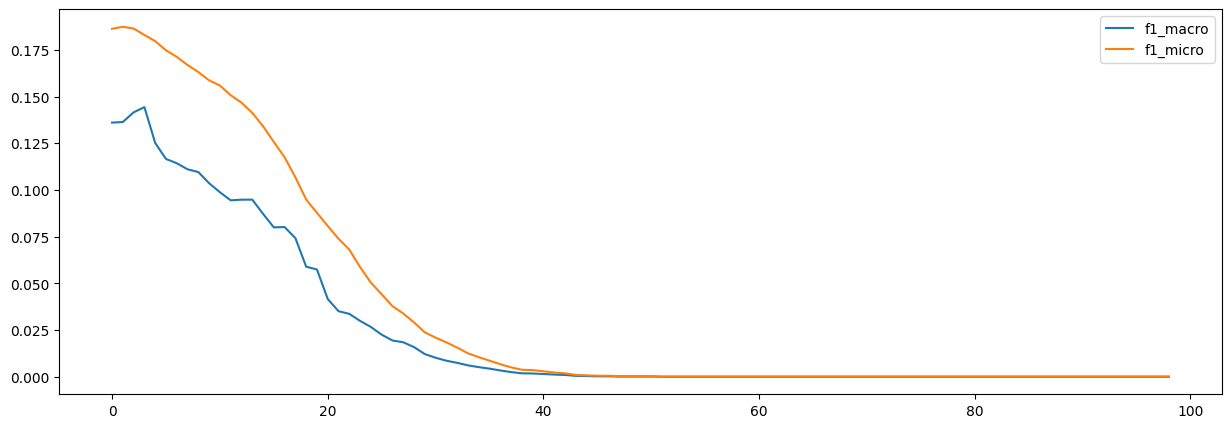

In [40]:
plt.figure(figsize=(15,5))
plt.plot([v['f1_macro'] for v in history['global_metrics']], label = 'f1_macro')
plt.plot([v['f1_micro'] for v in history['global_metrics']], label = 'f1_micro')
plt.legend()
plt.show()

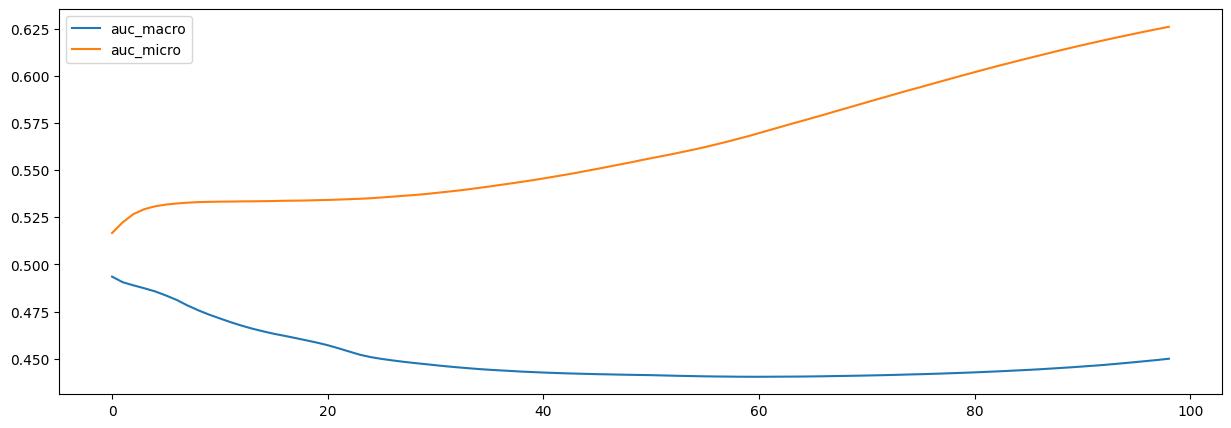

In [41]:
plt.figure(figsize=(15,5))
plt.plot([v['auc_macro'] for v in history['global_metrics']], label = 'auc_macro')
plt.plot([v['auc_micro'] for v in history['global_metrics']], label = 'auc_micro')
plt.legend()
plt.show()

# Centralized

In [47]:
def centralized_train(model, train_loader, val_loader, rounds, lr, epochs, device):
    """
    Train a single global model on combined data (centralized baseline).
    Tracks train loss, validation loss, and all evaluation metrics.
    """
    history = {
        "train_loss": [],
        "val_loss": [],
        "metrics": []  # stores full metric dict from eval_model
    }

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
    loss_fn = nn.BCEWithLogitsLoss()

    for r in tqdm(range(rounds), colour='green', desc="Centralized Training"):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation step after each round
        val_loss, metrics = eval_model(model=model, device=device, data_loader=val_loader)
        
        # Log values
        history["train_loss"].append(total_loss / len(train_loader))
        history["val_loss"].append(val_loss)
        history["metrics"].append(metrics)

        # # Optional progress logging
        # print(f"Round {r+1}/{rounds} | Train Loss: {total_loss/len(train_loader):.4f} | "
        #       f"Val Loss: {val_loss:.4f} | F1_macro: {metrics.get('f1_macro', 0):.4f}")

    return history


In [48]:
# Load all train and validation data (merged for centralized training)
train_loader = load_data('train')
val_loader = load_data('val')

# Create a new model (same architecture as FL)
centralized_model = GenerateModel(
    table_path=os.path.join('..', 'Model', 'processed_full.w2v'),
    num_of_filters=config['n_filters'],
    kernel_size=config['window_size']
).to(device)

# Train centralized model
centralized_history = centralized_train(
    model=centralized_model,
    train_loader=train_loader,
    val_loader=val_loader,
    rounds=config['rounds'],  # use same number of rounds for fair comparison
    lr=config['lr'],
    epochs=config['epochs'],
    device=device
)


Centralized Training:  40%|████      | 40/100 [02:37<03:54,  3.91s/it]c:\dev\FL-with-MIMIC\Replicating Mullenbach\Training Env\Env\evaluation.py:157: RuntimeWarning: invalid value encountered in scalar divide
  return intersect_size(yhatmic, ymic, 0) / yhatmic.sum(axis=0)
Centralized Training:  41%|████      | 41/100 [02:41<03:50,  3.90s/it]c:\dev\FL-with-MIMIC\Replicating Mullenbach\Training Env\Env\evaluation.py:157: RuntimeWarning: invalid value encountered in scalar divide
  return intersect_size(yhatmic, ymic, 0) / yhatmic.sum(axis=0)
Centralized Training:  42%|████▏     | 42/100 [02:45<03:46,  3.90s/it]c:\dev\FL-with-MIMIC\Replicating Mullenbach\Training Env\Env\evaluation.py:157: RuntimeWarning: invalid value encountered in scalar divide
  return intersect_size(yhatmic, ymic, 0) / yhatmic.sum(axis=0)
Centralized Training:  43%|████▎     | 43/100 [02:49<03:42,  3.91s/it]c:\dev\FL-with-MIMIC\Replicating Mullenbach\Training Env\Env\evaluation.py:157: RuntimeWarning: invalid value e

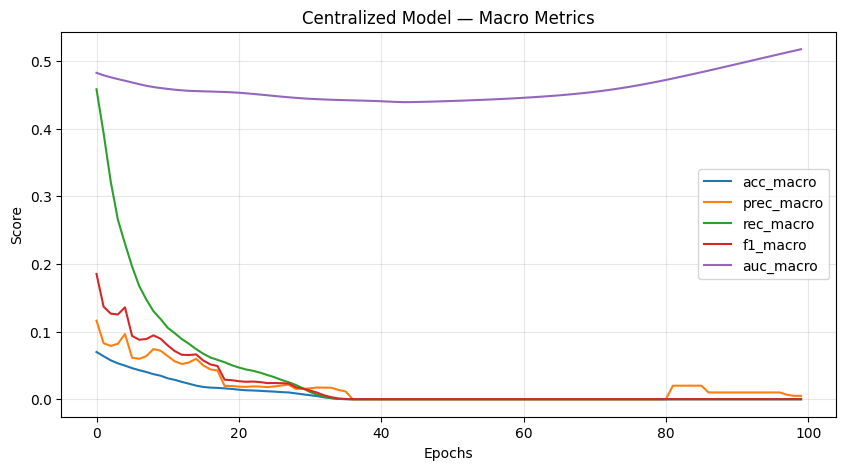

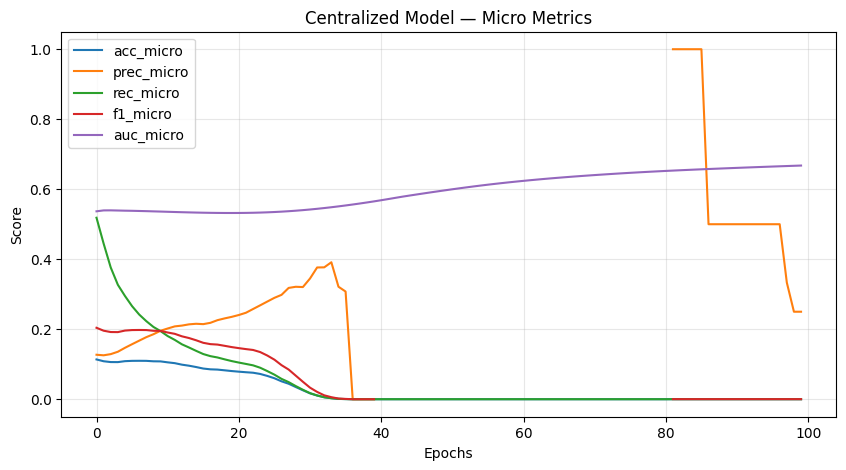

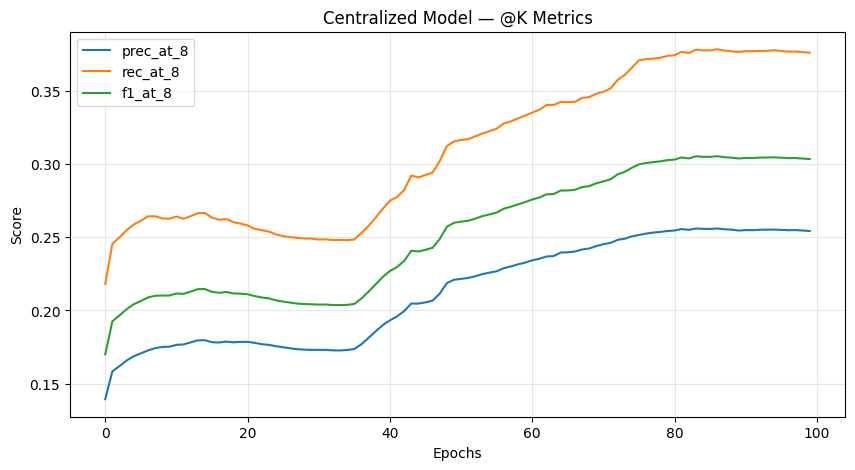

In [49]:
# --- Metric groups ---
macro_metrics = ['acc_macro', 'prec_macro', 'rec_macro', 'f1_macro', 'auc_macro']
micro_metrics = ['acc_micro', 'prec_micro', 'rec_micro', 'f1_micro', 'auc_micro']
atk_metrics   = ['prec_at_8', 'rec_at_8', 'f1_at_8']

def plot_metric_group(metrics, title, history_dict):
    """Plots grouped metrics (macro, micro, @K) for one training history."""
    plt.figure(figsize=(10, 5))
    for key in metrics:
        if key in history_dict[0]:
            plt.plot([v[key] for v in history_dict], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# --- Plot centralized metrics ---
plot_metric_group(macro_metrics, "Centralized Model — Macro Metrics", centralized_history["metrics"])
plot_metric_group(micro_metrics, "Centralized Model — Micro Metrics", centralized_history["metrics"])
plot_metric_group(atk_metrics,   "Centralized Model — @K Metrics",   centralized_history["metrics"])


# Compare the two

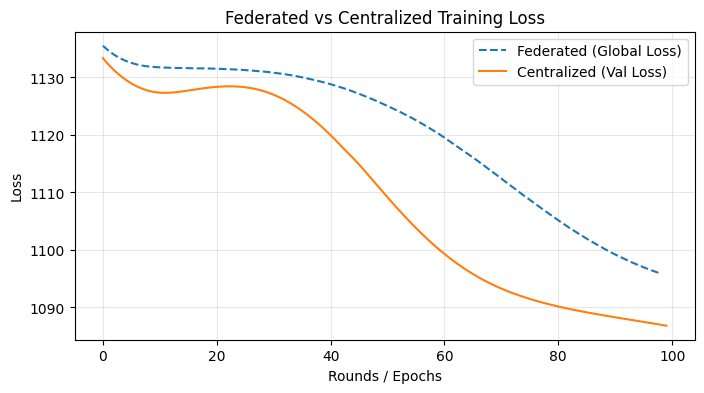

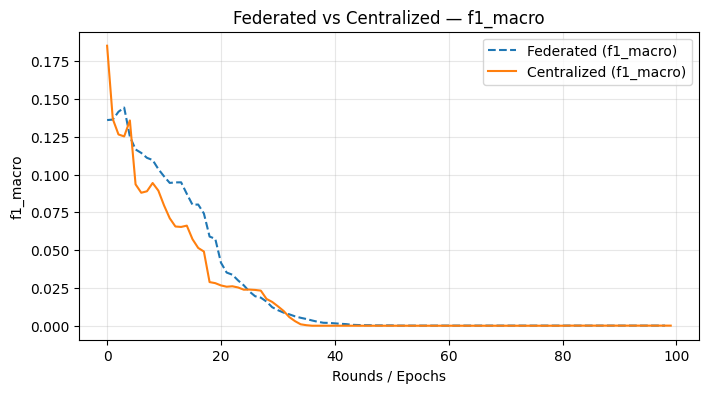

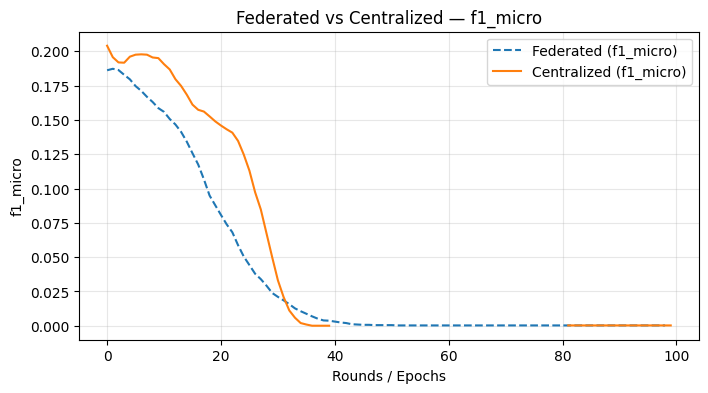

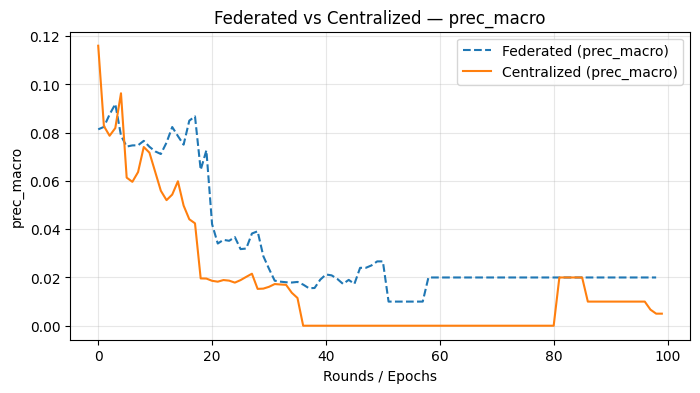

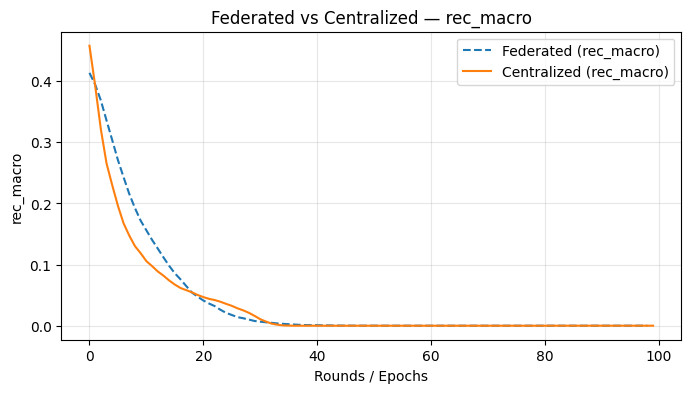

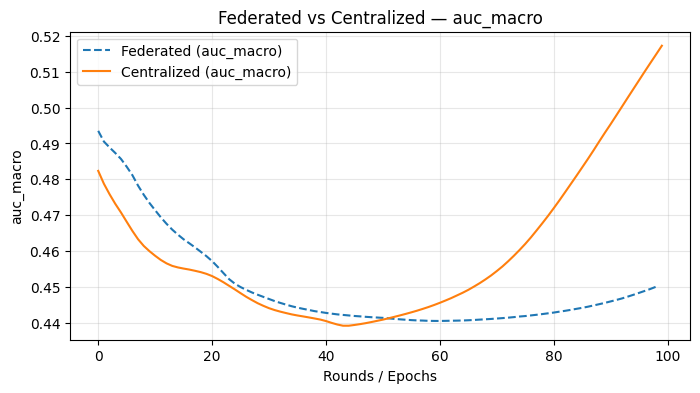

Federated Best F1 (Micro): 0.1873
Centralized Best F1 (Micro): 0.2041
Federated Best AUC (Macro): 0.4935
Centralized Best AUC (Macro): 0.5173


In [50]:
# -----------------------------
# 1️⃣ Compare Global vs Val Loss
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(history["global_loss"], label="Federated (Global Loss)", linestyle='--')
plt.plot(centralized_history["val_loss"], label="Centralized (Val Loss)", linestyle='-')
plt.xlabel("Rounds / Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Federated vs Centralized Training Loss")
plt.grid(alpha=0.3)
plt.show()


# -----------------------------
# 2️⃣ Compare Key Metrics
# -----------------------------
metrics_to_compare = ['f1_macro', 'f1_micro', 'prec_macro', 'rec_macro', 'auc_macro']

for metric in metrics_to_compare:
    if metric in history["global_metrics"][0] and metric in centralized_history["metrics"][0]:
        plt.figure(figsize=(8, 4))
        plt.plot([m[metric] for m in history["global_metrics"]],
                 label=f"Federated ({metric})", linestyle='--')
        plt.plot([m[metric] for m in centralized_history["metrics"]],
                 label=f"Centralized ({metric})", linestyle='-')
        plt.xlabel("Rounds / Epochs")
        plt.ylabel(metric)
        plt.title(f"Federated vs Centralized — {metric}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


# -----------------------------
# 3️⃣ Compare Best Metric Values
# -----------------------------
fed_best = max([m["f1_micro"] for m in history["global_metrics"]])
cent_best = max([m["f1_micro"] for m in centralized_history["metrics"]])
print(f"Federated Best F1 (Micro): {fed_best:.4f}")
print(f"Centralized Best F1 (Micro): {cent_best:.4f}")

fed_best_auc = max([m["auc_macro"] for m in history["global_metrics"]])
cent_best_auc = max([m["auc_macro"] for m in centralized_history["metrics"]])
print(f"Federated Best AUC (Macro): {fed_best_auc:.4f}")
print(f"Centralized Best AUC (Macro): {cent_best_auc:.4f}")
